In [767]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [768]:
# Import dataset
media = pd.read_csv('social_media_vs_productivity.csv')

In [769]:
# View the first five rows
media.head()

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


In [770]:
# Data shape 
media.shape

(30000, 19)

DATA PRE-PROCESSING

In [771]:
# Check for data types
media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

In [772]:
# Check for missing values 
media.isna().sum()

age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64

In [773]:
# Check for duplicates 
media.duplicated().sum()

0

In [774]:
# Drop missing values, since missing values are about 10% of the variables
media = media.dropna()

In [775]:
media.shape

(17074, 19)

EXPLORATORY DATA ANALYSIS

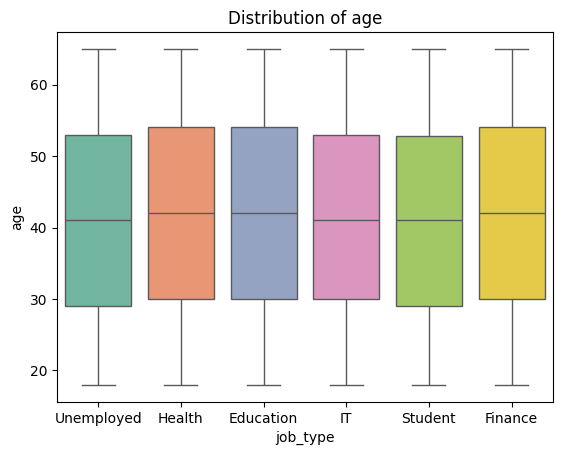

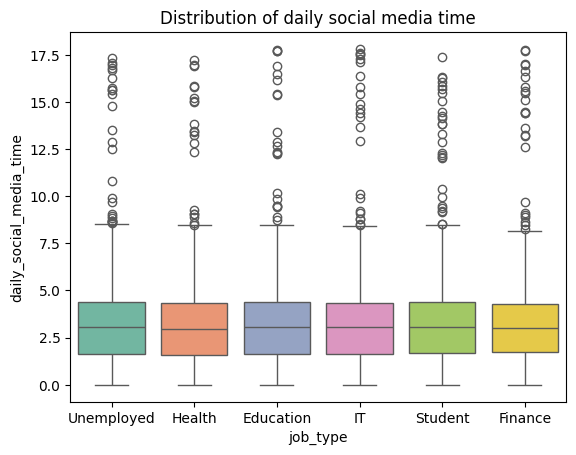

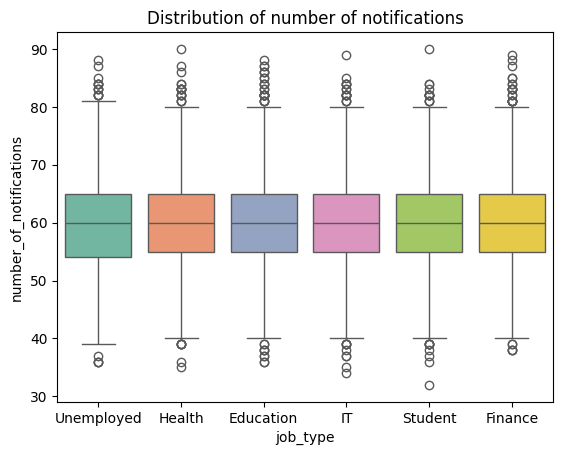

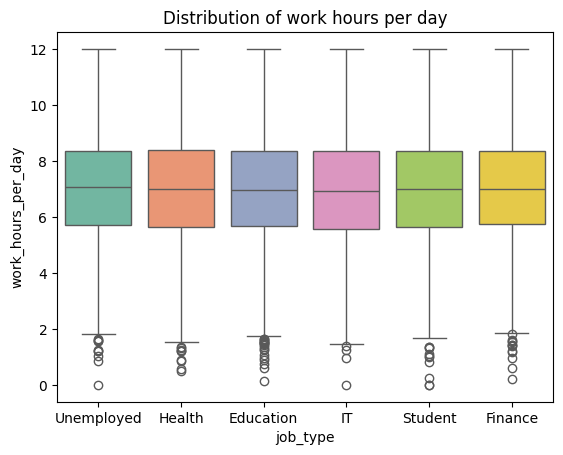

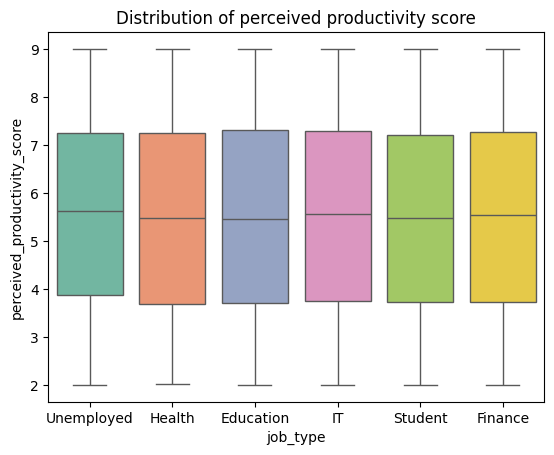

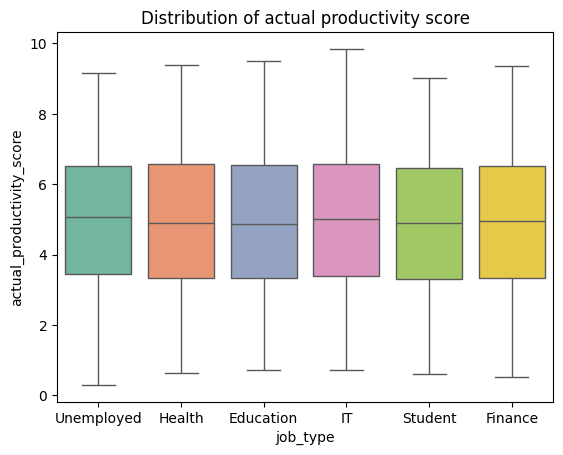

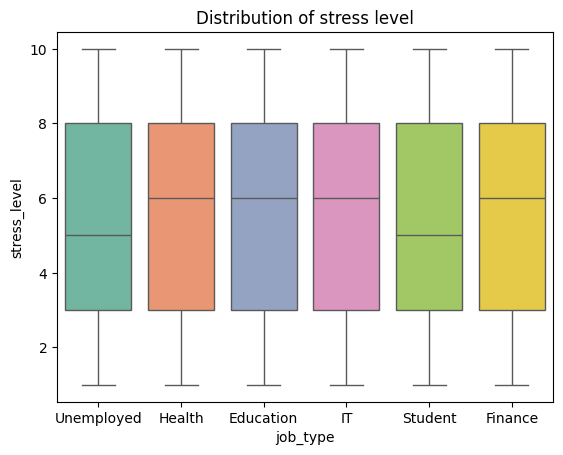

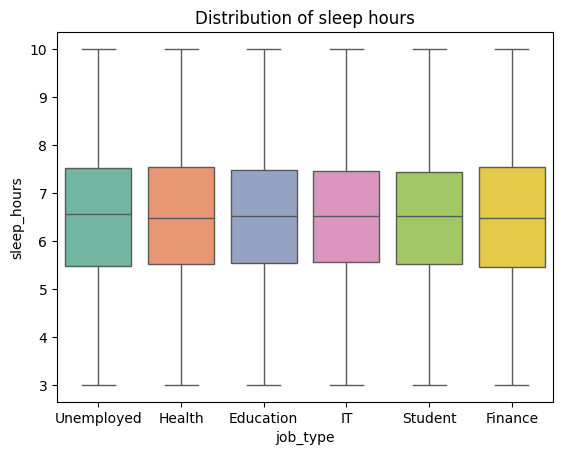

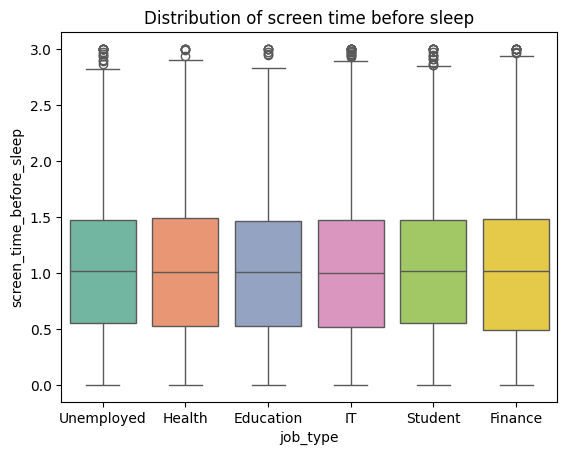

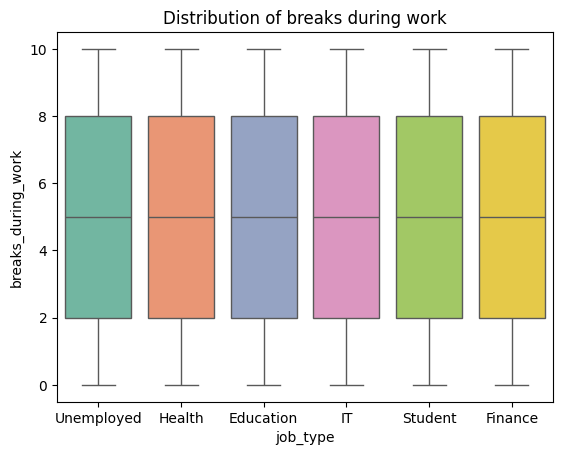

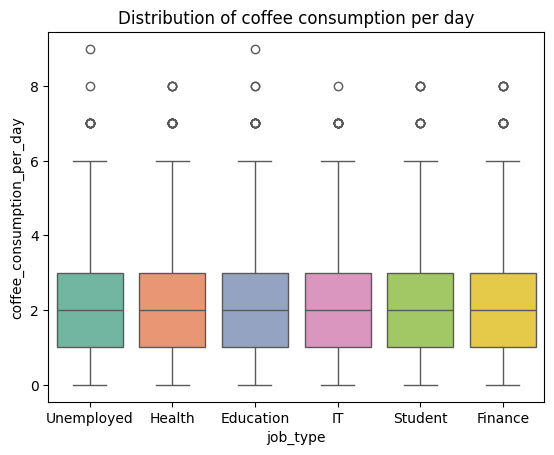

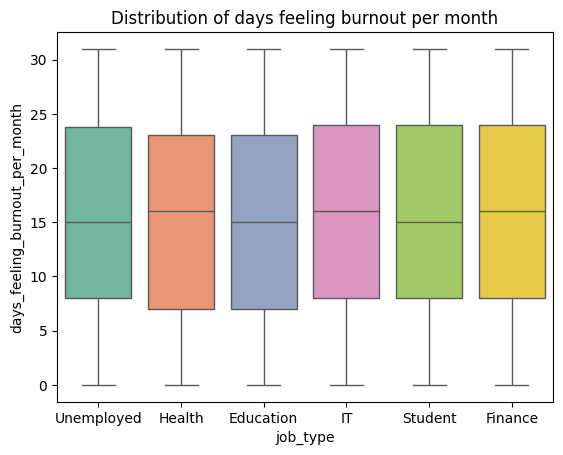

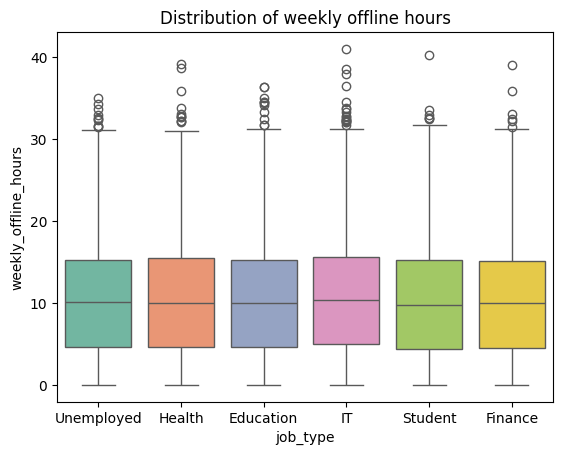

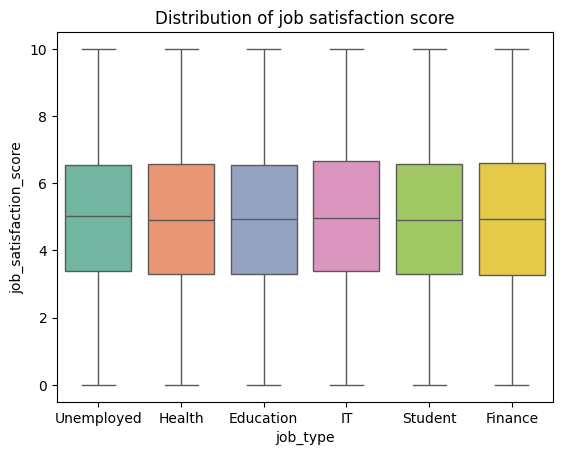

In [776]:
# Visualize the distribution of numerical variables with box plots 
numerical_columns = [col for col in media.columns if media[col].dtype in ['int64', 'float64']]
for col in numerical_columns:
    sns.boxplot(data = media, x = 'job_type', y = col, hue = 'job_type', palette ='Set2')
    plt.title(f'Distribution of {col.replace('_', ' ')}')
    plt.show()

- Overall, there is little difference in the distribution of numerical features across different job types. It is noticeable that 'Student' status not just includes people in the early 20s. 
- There are some columns with outliers , such as Daily Social Media Time, Work Hours and Screen Time Before Bed columns. This indicates that in the dataset, there are individuals who spent much more time than most people on social media, and also individuals who work more hours than others. These patterns possibly contribute to explaining the variation in productivity score

**Explore the difference in working habits between individuals of different job types**

In [777]:
media_filtered = media.groupby('job_type')[['actual_productivity_score','work_hours_per_day','stress_level','breaks_during_work','coffee_consumption_per_day','days_feeling_burnout_per_month','job_satisfaction_score']].mean()
media_filtered = media_filtered.reset_index()

In [778]:
media_filtered

,job_type,actual_productivity_score,work_hours_per_day,stress_level,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,job_satisfaction_score
0,Education,4.927931,6.972497,5.507804,4.984391,2.019771,15.253902,4.932090
1,Finance,4.942366,6.994088,5.561888,5.101748,1.987762,15.661189,4.920843
2,Health,4.918527,6.971429,5.505166,4.919131,1.997150,15.550410,4.959360
3,IT,4.970918,6.963666,5.555832,4.972973,2.034851,15.676743,4.992128
4,Student,4.907364,6.991727,5.441218,5.100420,1.983555,15.531141,4.907191
5,Unemployed,5.000258,7.045115,5.504205,4.926069,2.005957,15.572179,4.964843


In [779]:
# Job Type with highest and lowest stress level
media_filtered.sort_values('stress_level',ascending=False)

,job_type,actual_productivity_score,work_hours_per_day,stress_level,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,job_satisfaction_score
1,Finance,4.942366,6.994088,5.561888,5.101748,1.987762,15.661189,4.920843
3,IT,4.970918,6.963666,5.555832,4.972973,2.034851,15.676743,4.992128
0,Education,4.927931,6.972497,5.507804,4.984391,2.019771,15.253902,4.932090
2,Health,4.918527,6.971429,5.505166,4.919131,1.997150,15.550410,4.959360
5,Unemployed,5.000258,7.045115,5.504205,4.926069,2.005957,15.572179,4.964843
4,Student,4.907364,6.991727,5.441218,5.100420,1.983555,15.531141,4.907191


In [780]:
media_filtered.sort_values('work_hours_per_day',ascending=False)

,job_type,actual_productivity_score,work_hours_per_day,stress_level,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,job_satisfaction_score
5,Unemployed,5.000258,7.045115,5.504205,4.926069,2.005957,15.572179,4.964843
1,Finance,4.942366,6.994088,5.561888,5.101748,1.987762,15.661189,4.920843
4,Student,4.907364,6.991727,5.441218,5.100420,1.983555,15.531141,4.907191
0,Education,4.927931,6.972497,5.507804,4.984391,2.019771,15.253902,4.932090
2,Health,4.918527,6.971429,5.505166,4.919131,1.997150,15.550410,4.959360
3,IT,4.970918,6.963666,5.555832,4.972973,2.034851,15.676743,4.992128


In [781]:
# Job Type with the highest and lowest breaks during work
media_filtered.sort_values('breaks_during_work',ascending=False)

,job_type,actual_productivity_score,work_hours_per_day,stress_level,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,job_satisfaction_score
1,Finance,4.942366,6.994088,5.561888,5.101748,1.987762,15.661189,4.920843
4,Student,4.907364,6.991727,5.441218,5.100420,1.983555,15.531141,4.907191
0,Education,4.927931,6.972497,5.507804,4.984391,2.019771,15.253902,4.932090
3,IT,4.970918,6.963666,5.555832,4.972973,2.034851,15.676743,4.992128
5,Unemployed,5.000258,7.045115,5.504205,4.926069,2.005957,15.572179,4.964843
2,Health,4.918527,6.971429,5.505166,4.919131,1.997150,15.550410,4.959360


In [782]:
# Job Type with the highest and lowest coffee consumption per day
media_filtered.sort_values('coffee_consumption_per_day',ascending=False)

,job_type,actual_productivity_score,work_hours_per_day,stress_level,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,job_satisfaction_score
3,IT,4.970918,6.963666,5.555832,4.972973,2.034851,15.676743,4.992128
0,Education,4.927931,6.972497,5.507804,4.984391,2.019771,15.253902,4.932090
5,Unemployed,5.000258,7.045115,5.504205,4.926069,2.005957,15.572179,4.964843
2,Health,4.918527,6.971429,5.505166,4.919131,1.997150,15.550410,4.959360
1,Finance,4.942366,6.994088,5.561888,5.101748,1.987762,15.661189,4.920843
4,Student,4.907364,6.991727,5.441218,5.100420,1.983555,15.531141,4.907191


In [783]:
media_filtered.sort_values('days_feeling_burnout_per_month',ascending=False)

,job_type,actual_productivity_score,work_hours_per_day,stress_level,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,job_satisfaction_score
3,IT,4.970918,6.963666,5.555832,4.972973,2.034851,15.676743,4.992128
1,Finance,4.942366,6.994088,5.561888,5.101748,1.987762,15.661189,4.920843
5,Unemployed,5.000258,7.045115,5.504205,4.926069,2.005957,15.572179,4.964843
2,Health,4.918527,6.971429,5.505166,4.919131,1.997150,15.550410,4.959360
4,Student,4.907364,6.991727,5.441218,5.100420,1.983555,15.531141,4.907191
0,Education,4.927931,6.972497,5.507804,4.984391,2.019771,15.253902,4.932090


In [784]:
media_filtered.sort_values('job_satisfaction_score',ascending=False)

,job_type,actual_productivity_score,work_hours_per_day,stress_level,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,job_satisfaction_score
3,IT,4.970918,6.963666,5.555832,4.972973,2.034851,15.676743,4.992128
5,Unemployed,5.000258,7.045115,5.504205,4.926069,2.005957,15.572179,4.964843
2,Health,4.918527,6.971429,5.505166,4.919131,1.997150,15.550410,4.959360
0,Education,4.927931,6.972497,5.507804,4.984391,2.019771,15.253902,4.932090
1,Finance,4.942366,6.994088,5.561888,5.101748,1.987762,15.661189,4.920843
4,Student,4.907364,6.991727,5.441218,5.100420,1.983555,15.531141,4.907191


In [785]:
media_filtered.sort_values('actual_productivity_score',ascending=False)

,job_type,actual_productivity_score,work_hours_per_day,stress_level,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,job_satisfaction_score
5,Unemployed,5.000258,7.045115,5.504205,4.926069,2.005957,15.572179,4.964843
3,IT,4.970918,6.963666,5.555832,4.972973,2.034851,15.676743,4.992128
1,Finance,4.942366,6.994088,5.561888,5.101748,1.987762,15.661189,4.920843
0,Education,4.927931,6.972497,5.507804,4.984391,2.019771,15.253902,4.932090
2,Health,4.918527,6.971429,5.505166,4.919131,1.997150,15.550410,4.959360
4,Student,4.907364,6.991727,5.441218,5.100420,1.983555,15.531141,4.907191


- The 'unemployed' are those with highest average work hours per day, but having the highest average productivity score. This possibly indicates that these people do freelance work, they they are not bound by fixed schedules and can work at times that suit them best, which often results in improved efficiency. Therefore, they have higher job satisfaction score (rank second) and lower stress level (rank second to last), compared to other job
- People working in Finance, despite having highest average breaks during work hours, have the highest average stress levels (5.56/10). They also have higher coffee consumption level (rank second) and lower job satisfaction level (rank second to last). This could be due to the nature of Finance job: high-pressure, fast-paced and work with lots of numbers 
- IT sector has highest average days feeling burnout per month, highest coffee consumption per day, but having highest average job satisfaction score. One possible reason for this is because they have the lowest average work hours per day 
- Employees in Education sector have lowest average days feeling burn-out per month
- People working in Health have lower average productivity score, which is partly caused by having the lowest average breaks during work  

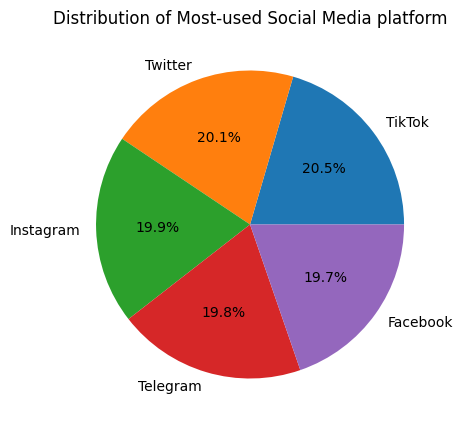

In [786]:
# Distribution of Most-preferred Social Media Platform
ax = media['social_platform_preference'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    figsize=(5,5)
)
ax.set_title('Distribution of Most-used Social Media platform')
ax.set_ylabel(None)
plt.show()


In [787]:
media.groupby('social_platform_preference')['daily_social_media_time'].mean()

social_platform_preference
Facebook     3.154216
Instagram    3.113158
Telegram     3.054361
TikTok       3.197902
Twitter      3.091246
Name: daily_social_media_time, dtype: float64

- The analysis shows that there is no discrepancy between the five social platforms in terms of preference. TikTok and Twitter are two most favourite apps chosen by users
- Users also spent an average of 3 hours and 12 minutes on TikTok, the highest amount among 5 platforms. Facebook comes in second place with an average of 3 hours and 9 minutes per day
- Telegram ranks last both in terms of preference and time spent

**Explore the difference in social-media using habits of different job types**

In [788]:
media_filtered_2 = media.groupby('job_type')[['screen_time_before_sleep','weekly_offline_hours']].median()
media_filtered_2 = media_filtered_2.reset_index()

In [789]:
media_filtered_2.sort_values('screen_time_before_sleep',ascending=False)

,job_type,screen_time_before_sleep,weekly_offline_hours
5,Unemployed,1.018831,10.046266
4,Student,1.015996,9.783915
1,Finance,1.013768,9.918367
2,Health,1.006907,10.008904
0,Education,1.004674,9.942107
3,IT,0.996581,10.297724


In [790]:
media_filtered_2.sort_values('weekly_offline_hours',ascending=False)

,job_type,screen_time_before_sleep,weekly_offline_hours
3,IT,0.996581,10.297724
5,Unemployed,1.018831,10.046266
2,Health,1.006907,10.008904
0,Education,1.004674,9.942107
1,Finance,1.013768,9.918367
4,Student,1.015996,9.783915


- People working in IT have the highest weekly offline hours (excluding sleep time) and spend least time on screens before bed. 
- On the other hand, freelancers ('Unemployed'), students and finance people indulge in heavy screen time before sleeping. Moreover, students and finance workers have less time staying  away from social media, highlighting a bad habit in social media usage. 

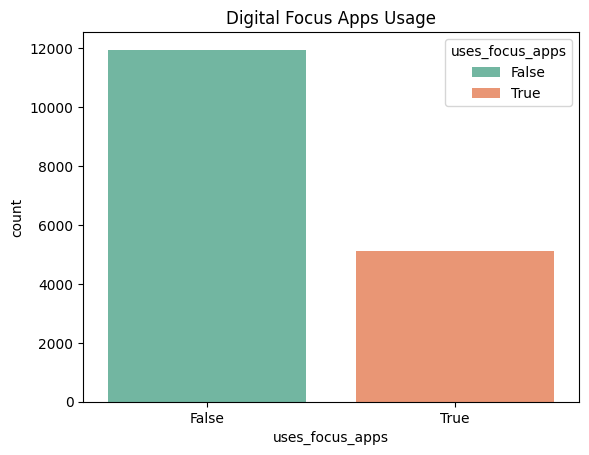

In [791]:
sns.countplot(data = media, x = 'uses_focus_apps', hue = 'uses_focus_apps' , palette = 'Set2')
plt.title('Digital Focus Apps Usage')
plt.show()

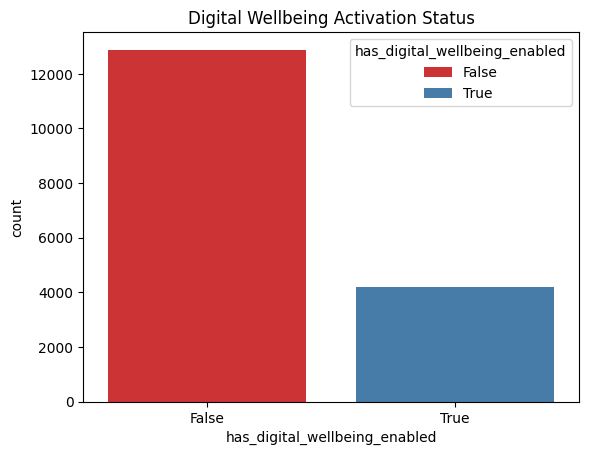

In [792]:
sns.countplot(data = media, x = 'has_digital_wellbeing_enabled', hue = 'has_digital_wellbeing_enabled' , palette = 'Set1')
plt.title('Digital Wellbeing Activation Status')
plt.show()

Two plots show that there are fewer people who used digital focus apps or had digital wellbeing features activated. This means that people do not actively find ways to manage their social media usage and maintain a healthy relationship with the phone, such as managing screen time and reducing distractions from work and study

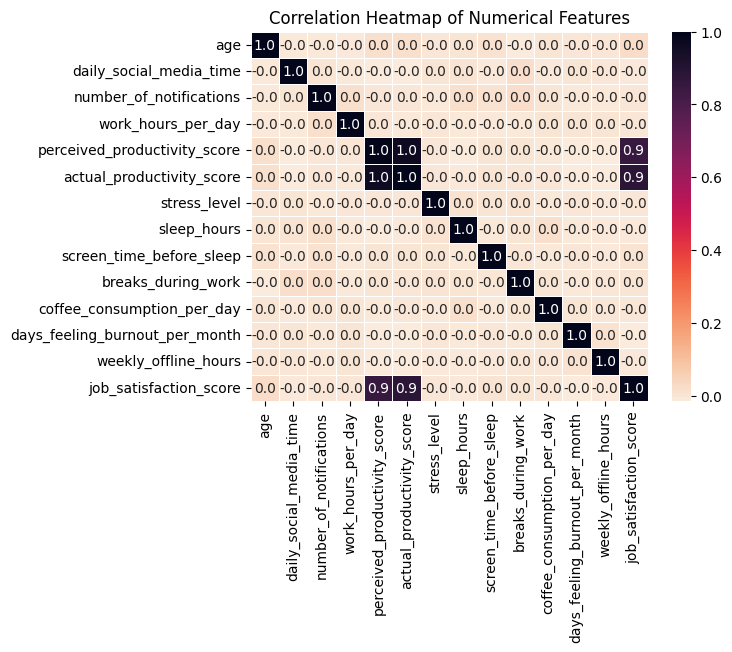

In [793]:
# Visualize the correlation between numerical features
sns.heatmap(media[numerical_columns].corr(), annot=True, cmap='rocket_r', fmt='.1f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

The heatmap shows that only three variables, job_satisfaction_score, perceived_productivity_score and actual_productivity_score are highly correlated with each other, in a pair-wise relationship. This indicates that individuals who achived high job satisfaction also tend to find themselves more productive. Also, the close relationship between perceived_productivity_score and actual_productivity_score implies that self-assessment of productivity aligns closely with objective measurements and self-measurement of productivity score could be a reliable measurement.

**DATA PRE-PROCESSING FOR REGRESSION ANALYSIS**

In [794]:
# Winsorize columns with outliers 
columns_with_outliers = ['number_of_notifications','daily_social_media_time','work_hours_per_day','screen_time_before_sleep','coffee_consumption_per_day','weekly_offline_hours']

In [795]:
from scipy.stats import mstats
for col in columns_with_outliers:
    media[col] = mstats.winsorize(media[col],limits=[0.05,0.05])

In [796]:
categorical_columns = [col for col in media.columns if media[col].dtype =='object']

In [797]:
categorical_columns

['gender', 'job_type', 'social_platform_preference']

In [798]:
# Perform one-hot encoding on categorical columns
media = pd.get_dummies(media, columns=categorical_columns, drop_first=True, dtype=float)

In [799]:
# Convert boolean columns to '0' (False) and '1' (True)
media['uses_focus_apps'] = media['uses_focus_apps'].map({False:0,True:1})
media['has_digital_wellbeing_enabled'] = media['has_digital_wellbeing_enabled'].map({False:0,True:1})

In [800]:
media.isna().sum()

age                                     0
daily_social_media_time                 0
number_of_notifications                 0
work_hours_per_day                      0
perceived_productivity_score            0
actual_productivity_score               0
stress_level                            0
sleep_hours                             0
screen_time_before_sleep                0
breaks_during_work                      0
uses_focus_apps                         0
has_digital_wellbeing_enabled           0
coffee_consumption_per_day              0
days_feeling_burnout_per_month          0
weekly_offline_hours                    0
job_satisfaction_score                  0
gender_Male                             0
gender_Other                            0
job_type_Finance                        0
job_type_Health                         0
job_type_IT                             0
job_type_Student                        0
job_type_Unemployed                     0
social_platform_preference_Instagr

In [801]:
media.head()

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,...,gender_Other,job_type_Finance,job_type_Health,job_type_IT,job_type_Student,job_type_Unemployed,social_platform_preference_Instagram,social_platform_preference_Telegram,social_platform_preference_TikTok,social_platform_preference_Twitter
0,56,4.180940,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,46,3.249603,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,56,4.381070,60,3.902309,6.420989,5.976408,7.0,7.549849,2.148545,4,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,36,4.089168,49,6.560467,2.681830,2.446927,4.0,6.325507,0.747998,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10,28,3.341559,57,10.318704,8.940636,7.983252,4.0,3.952547,1.028640,5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [802]:
media.columns

Index(['age', 'daily_social_media_time', 'number_of_notifications',
       'work_hours_per_day', 'perceived_productivity_score',
       'actual_productivity_score', 'stress_level', 'sleep_hours',
       'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps',
       'has_digital_wellbeing_enabled', 'coffee_consumption_per_day',
       'days_feeling_burnout_per_month', 'weekly_offline_hours',
       'job_satisfaction_score', 'gender_Male', 'gender_Other',
       'job_type_Finance', 'job_type_Health', 'job_type_IT',
       'job_type_Student', 'job_type_Unemployed',
       'social_platform_preference_Instagram',
       'social_platform_preference_Telegram',
       'social_platform_preference_TikTok',
       'social_platform_preference_Twitter'],
      dtype='object')

**LINEAR REGRESSION** 

In [803]:
import statsmodels.api as sm

In [804]:
# Define features and target variable
y = media['actual_productivity_score']
X = media.drop(columns =['actual_productivity_score','perceived_productivity_score'])

In [805]:
# Add the intercept
X = sm.add_constant(X) 

In [806]:
# Fit the model 
model = sm.OLS(y, X).fit()

In [807]:
# Model summary 
print(model.summary())

                                OLS Regression Results                               
Dep. Variable:     actual_productivity_score   R-squared:                       0.781
Model:                                   OLS   Adj. R-squared:                  0.781
Method:                        Least Squares   F-statistic:                     2433.
Date:                       Sat, 31 May 2025   Prob (F-statistic):               0.00
Time:                               01:20:35   Log-Likelihood:                -22117.
No. Observations:                      17074   AIC:                         4.429e+04
Df Residuals:                          17048   BIC:                         4.449e+04
Df Model:                                 25                                         
Covariance Type:                   nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

**Results from multiple linear regression** 
- F-statistic > 1: We can reject the null hypothesis and conclude that there is at least one independent variable that can be used to explain the dependent variable
- R-squared = 0.781: 78.1% of the variability in the dependent variable (actual_productivity_score) is explained by the model. This indicates a robust model
- The corresponding p-values show that, in the presence of the other regressor variables, only the effects of daily_social_media_time,job_satisfaction_score, gender_Male and job_type_Unemployed variables are significant at the 5% level (p-value < 0.05)
- A negative coefficient for daily_social_media_time variable means that increasing time spent on social media will reduce  productivity, keeping other variables constant
- A positive coefficient for job_satisfaction_score variable means that individuals who are satisfied with their job, are also highly likely to be productive 
- Male users tend to have lower productivity score than Female users (negative coefficient)
- Unemployed people (freelancers) are more productive than people working in Education field
* gender_Female and job_type_Education are used as baseline